# Flow-matching with `flowflusion`

This notebook demonstrates how to work with the `flowfusion.flow` module. It will show how to setup a simple continuous normalizing flow and train this via flow-matching. It will also look at how we can work with the trained model to:
 1. generate samples; and
 2. evaluate the log probability density.

## Generating a toy example

First, we can generate some training data from a 2D density.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import time

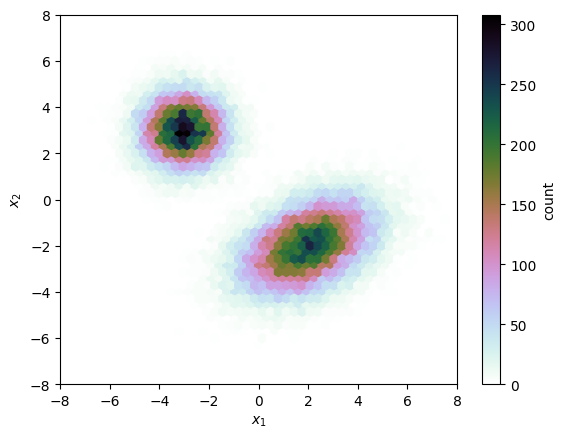

In [2]:
# sample from a two-component mixture model
mu_1 = torch.tensor([-3.0, 3.0]) # means
mu_2 = torch.tensor([2.0, -2.0])
C_1  = torch.tensor([[1.0, 0.0], [0.0, 1.0]]) # covariances
C_2  = torch.tensor([[2.0, 0.9], [0.9, 2.0]])
L_1  = torch.linalg.cholesky(C_1)
L_2  = torch.linalg.cholesky(C_2)
w_1  = 0.4 # component weights
w_2  = 0.6

def gmm_log_prob(x, mu_1=mu_1, mu_2=mu_2, C_1=C_1, C_2=C_2, w_1=w_1, w_2=w_2):
    """
    Compute log probability for two-component GMM.
    
    Parameters
    ----------
    x : torch.tensor
        Tensor to compute log prob for.
    mu_1 : torch.tensor, optional
        Length-2 vector with mean of component 1.
    mu_2 : torch.tensor, optional
        Length-2 vector with mean of component 2.
    C_1 : torch.tensor, optional
        Component 1's covariance (2x2).
    C_2 : torch.tensor, optional
        Component 2's covariance (2x2).
    w_1 : float, optional
        Weight of component 1.
    w_2 : float, optional
        Weight of component 2.
        
    Returns
    -------
    lp : torch.tensor
        Log probabilities for all rows in x.
    """
    lp_1 = - 0.5*torch.linalg.slogdet(2.0*np.pi*C_1)[1] \
            - 0.5*torch.sum((x - mu_1)*torch.linalg.solve(C_1, x - mu_1, left=False), dim=1)
    lp_2 = - 0.5*torch.linalg.slogdet(2.0*np.pi*C_2)[1] \
            - 0.5*torch.sum((x - mu_2)*torch.linalg.solve(C_2, x - mu_2, left=False), dim=1)
    
    lp = torch.logaddexp(np.log(w_1) + lp_1, np.log(w_2) + lp_2)
    return lp
    
def gmm_rand(N, mu_1=mu_1, mu_2=mu_2, L_1=L_1, L_2=L_2, w_1=w_1, w_2=w_2, shuffle=True):
    """
    Generate random draw from two-component GMM.
    
    Parameters
    ----------
    N : int
        Total number of samples to generate.
    mu_1 : torch.tensor, optional
        Length-2 vector with mean of component 1.
    mu_2 : torch.tensor, optional
        Length-2 vector with mean of component 2.
    L_1 : torch.tensor, optional
        Cholesky factor of component 1's covariance (2x2).
    L_2 : torch.tensor, optional
        Cholesky factor of component 2's covariance (2x2).
    w_1 : float, optional
        Weight of component 1.
    w_2 : float, optional
        Weight of component 2.
    shuffle : bool, optional
        If True, shuffles the rows. 
        If False, stacks the draws from the first and second components.
    
    Returns
    -------
    x : torch.tensor
        Random vector drawn from GMM.
    """
    N_1 = int(N*w_1)
    N_2 = N - N_1

    x = torch.randn(N, 2)
    x[:N_1] = mu_1 + x[:N_1] @ L_1
    x[N_1:] = mu_2 + x[N_1:] @ L_2
    if shuffle is True:
        idx = torch.randperm(N)
        x = x[idx]
    return x
    
N = 50000 # number of samples
x = gmm_rand(N)

plt.hexbin(x[:,0], x[:,1], cmap='cubehelix_r', extent=(-8,8,-8,8), gridsize=50)
plt.colorbar(label='count')
plt.xlim(-8,8)
plt.ylim(-8,8)
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.show()

## Setting up a model

To set up a model, we will need to initialize an `ODEFlow` model, which will use a simple multi-layer perceptron (MLP) to model the dynamics of the flow between a Gaussian base density and our target.

In [3]:
from flowfusion.flow import ODEFlow

We can create an instance of this class with the correct target dimension and a 3-layer MLP for the dynamics.

In [4]:
# ODE flow class with MLP for the dynamics
ode_model = ODEFlow(target_dimension=2, hidden_units=[128,128,128])

## Training the model

Now, we can train our model via flow-matching, given the samples from our toy density. We'll use a simple training loop where the batch size and learning rate are stepped synchronously. We'll split our toy density samples into training:validation:test with a ratio 25:25:50%.

In [5]:
from torch.utils.data import DataLoader, TensorDataset, random_split
from torch.optim import Adam
from tqdm import trange

# train:val:test split
x_train, x_val, x_test = random_split(x, (0.25, 0.25, 0.5))

# number of training epochs per batch size/learning rate step
epochs = 250

training...
batch size: 32
learning rate: 0.001


100%|██████████████████████████████████████████████████████████████████████████████████████████| 250/250 [01:09<00:00,  3.61it/s]


batch size: 64
learning rate: 0.0001


100%|██████████████████████████████████████████████████████████████████████████████████████████| 250/250 [00:42<00:00,  5.88it/s]


batch size: 128
learning rate: 1e-05


100%|██████████████████████████████████████████████████████████████████████████████████████████| 250/250 [00:29<00:00,  8.38it/s]


batch size: 256
learning rate: 1e-06


100%|██████████████████████████████████████████████████████████████████████████████████████████| 250/250 [00:21<00:00, 11.41it/s]


done!


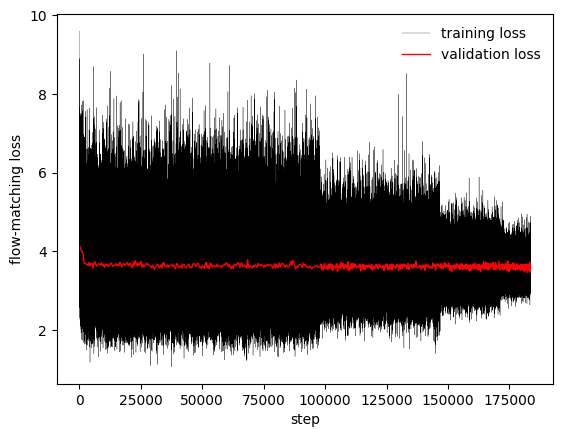

In [6]:
losses = []
val_losses = []
steps_per_epoch = []

# training loop
print('training...')
# outer loop over batch sizes and learning rates
for bs, lr in zip ([32, 64, 128, 256], [1e-03, 1e-04, 1e-05, 1e-06]):
    print('batch size:', bs)
    print('learning rate:', lr)
    # optimizer and data-loader for this round
    optimizer = Adam(ode_model.velocity.parameters(), lr=lr)
    data_loader = DataLoader(x_train, shuffle=True, batch_size=bs)
    # inner loop over epochs
    for epoch in trange(epochs):
        c = 0 # no. of mini-batches
        # loop over mini-batches
        for xt in data_loader:
            optimizer.zero_grad()
            # FM loss function
            loss = ode_model.flow_matching_loss(xt)
            loss.backward()
            optimizer.step()
            losses.append(loss.detach().numpy())
            c += 1
        # FM loss for validation dataset
        val_loss = ode_model.flow_matching_loss(x_val.dataset[x_val.indices])
        val_losses.append(val_loss.detach().numpy())
        steps_per_epoch.append(c)
print('done!')

ode_model.eval()

# plot the loss curve (train and validation)
plt.plot(1+np.arange(len(losses)), losses, color='k', linewidth=0.2, label='training loss')
plt.plot(np.cumsum(steps_per_epoch), val_losses, color='r', linewidth=1.0, label='validation loss')
plt.xlabel('step')
plt.ylabel('flow-matching loss')
plt.legend(frameon=False)
plt.show()

## Sampling from the trained model

Now we've trained our model, we can try to generate some samples from it. This will be done by solving an ODE backwards in time from an initial state drawn from the base density.

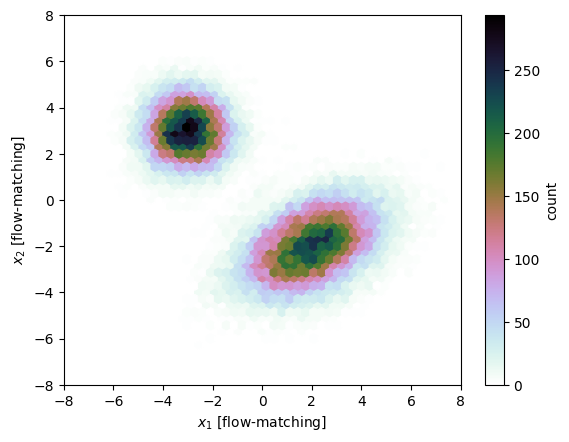

In [7]:
# generate samples by integrating reverse-time ODE
# this requires some N(0,1) samples as input, and will be deterministic given these
x_pred_ode = ode_model.sample(torch.randn(50000, 2)).detach().numpy()

# make a plot like we did in the first cell
# hopefully it'll look like that plot!
plt.hexbin(x_pred_ode[:,0], x_pred_ode[:,1], cmap='cubehelix_r', extent=(-8,8,-8,8), gridsize=50)
plt.colorbar(label='count')
plt.xlim(-8,8)
plt.ylim(-8,8)
plt.xlabel('$x_1$ [flow-matching]')
plt.ylabel('$x_2$ [flow-matching]')
plt.show()

## Calculating log probabilities
Now, we can try to use the trained model to compute log probabilities of the test set. We'll do this via another ODE solve.

In [8]:
# compute the true log probabilities
lp_true = gmm_log_prob(x_test.dataset[x_test.indices])

# compute log prob using ODE solve
start = time.time()
lp_ode_exact = ode_model.log_prob(x_test.dataset[x_test.indices], atol=1e-4, rtol=1e-4).detach().numpy()
end = time.time()
print('Exact trace:', end - start, 's')

Exact trace: 10.792315006256104 s


In [9]:
print('Truth:', lp_true.sum().item())
print('Exact trace:', lp_ode_exact.sum().item())

Truth: -96783.375
Exact trace: -96390.4453125


Now let's plot the log probabilities of individual samples as a scatter plot.

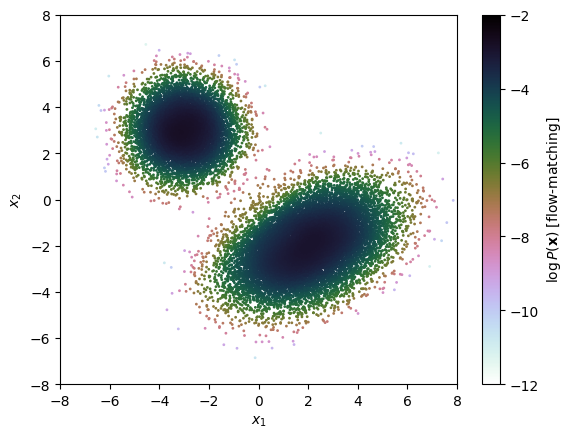

In [10]:
plt.scatter(x_test.dataset[x_test.indices,0], x_test.dataset[x_test.indices,1], c=lp_ode_exact, s=1.0, cmap='cubehelix_r', vmin=-12, vmax=-2)
plt.colorbar(label='$\\log P(\\mathbf{x})$ [flow-matching]')
plt.xlim(-8,8)
plt.ylim(-8,8)
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.show()